In [124]:
import numpy as np  
import matplotlib.pyplot as plt

(35.0, 50.0)

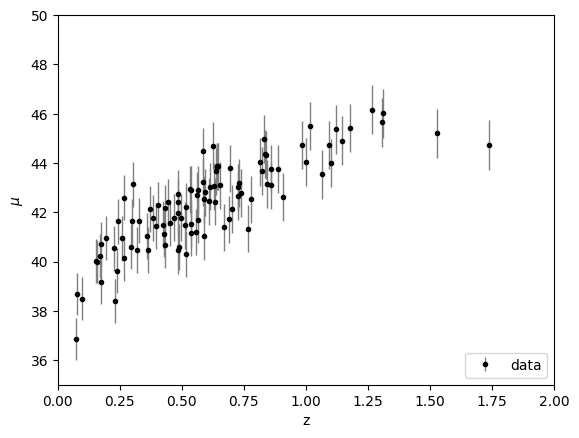

In [125]:
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50)


### Let's perform a GPR 

In [126]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, DotProduct 


# Radial basis function kernel RBF 
kernel1 = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) #one possible kernel choice

z = np.linspace(0.01, 2, 1000)

gp = GaussianProcessRegressor(kernel=kernel1, alpha=dmu ** 2)

gp.fit(z_sample[:, None], mu_sample)            #fit the data 
mu_fit, sigma = gp.predict(z[:, None], return_std=True)             #return the main, Standard deviation of predictive distribution


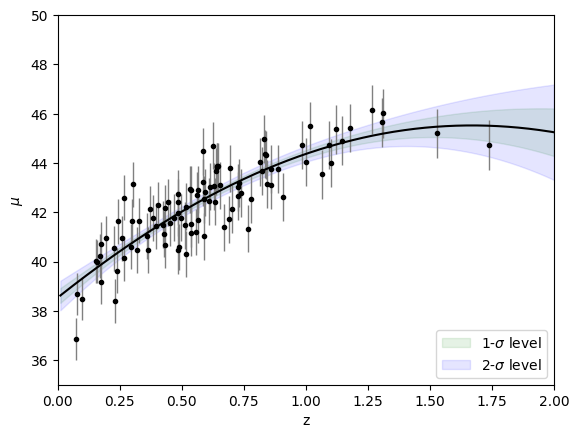

In [127]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.plot(z, mu_fit, '-k')

plt.fill_between(z, mu_fit - sigma, mu_fit + sigma, alpha=0.1, color='g', label='1-$\sigma$ level')

plt.fill_between(z, mu_fit - 2* sigma, mu_fit + 2* sigma, alpha=0.1, color='b', label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

### Cross validation to chose the Kernel Hyperparameter

There is already an optimization of the kernel Hyperparameter (indeed with we give a initial guess and an interval) so I cross validate using different Kernel

In [128]:
from sklearn.model_selection import GridSearchCV, KFold

kernels= [ConstantKernel(1.0, (1e-3, 1e4)) * RBF(10, (1e-2, 1e3)),
          ConstantKernel(1.0, (1e-3, 1e4)),
          RBF(10, (1e-2, 1e3)), 
          Matern(1.0, (1e-3, 1e3))]

cv = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "kernel": kernels
}

gpr = GaussianProcessRegressor(kernel=kernels,alpha=0.9) 
search = GridSearchCV(
    estimator=gpr,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_squared_error",  # puoi anche usare R^2 o MAE
    n_jobs=-1,
    verbose=1
)

search.fit(z_sample[:, None], mu_sample)


Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GaussianProcessRegressor(alpha=0.9,
                                                kernel=[1**2 * RBF(length_scale=10),
                                                        1**2,
                                                        RBF(length_scale=10),
                                                        Matern(length_scale=1, nu=1.5)]),
             n_jobs=-1,
             param_grid={'kernel': [1**2 * RBF(length_scale=10), 1**2,
                                    RBF(length_scale=10),
                                    Matern(length_scale=1, nu=1.5)]},
             scoring='neg_mean_squared_error', verbose=1)

Best kernel: 30.6**2 * RBF(length_scale=3.93)


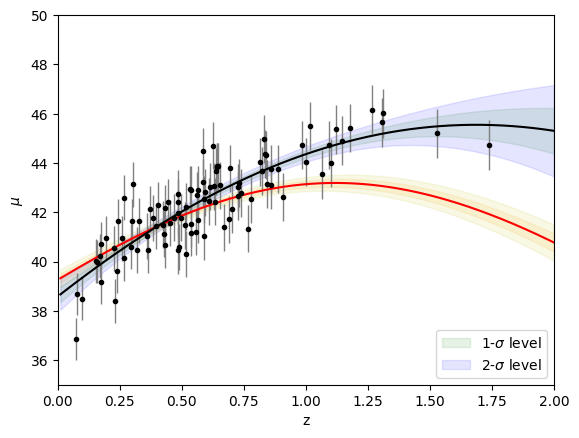

In [129]:
gp_best = search.best_estimator_
print("Best kernel:", gp_best.kernel_)

mu_fit2, sigma2 = gp_best.predict(z[:, None], return_std=True)

kernel2=Matern(1.0, (1e-3, 1e3))
gp3 = GaussianProcessRegressor(kernel=kernel2, alpha=dmu ** 2)

gp3.fit(z_sample[:, None], mu_sample)            #fit the data 
mu_fit3, sigma3 = gp3.predict(z[:, None], return_std=True)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1)

plt.plot(z, mu_fit3, '-r')

plt.fill_between(z, mu_fit3 - sigma3, mu_fit3 + sigma3, alpha=0.1, color='orange')

plt.fill_between(z, mu_fit3 - 2* sigma3, mu_fit3 + 2* sigma3, alpha=0.1, color='y')

plt.plot(z, mu_fit2, '-k')

plt.fill_between(z, mu_fit2 - sigma2, mu_fit2 + sigma2, alpha=0.1, color='g', label='1-$\sigma$ level')

plt.fill_between(z, mu_fit2 - 2* sigma2, mu_fit2 + 2* sigma2, alpha=0.1, color='b', label='2-$\sigma$ level')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


### Cloning data

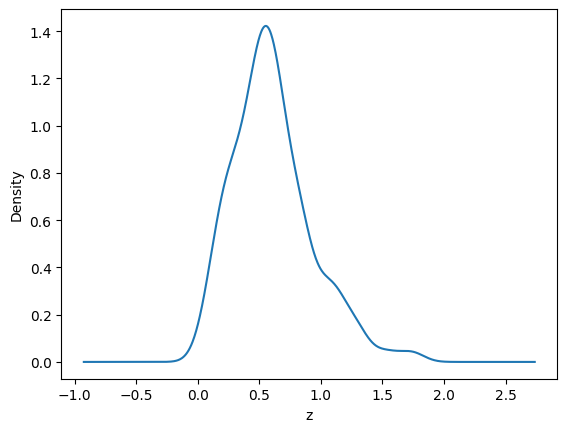

In [130]:
#VISUALIZE THE DISTRIBUTION OF DATA in z

from sklearn.neighbors import KernelDensity

z_vals = np.array(z_sample).reshape(-1, 1) 

kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(z_vals)

z_plot = np.linspace(z_vals.min() - 1, z_vals.max() + 1, 1000).reshape(-1, 1)
log_dens = kde.score_samples(z_plot)
dens = np.exp(log_dens)

plt.plot(z_plot[:, 0], dens)
plt.xlabel('z')
plt.ylabel('Density')
plt.show()

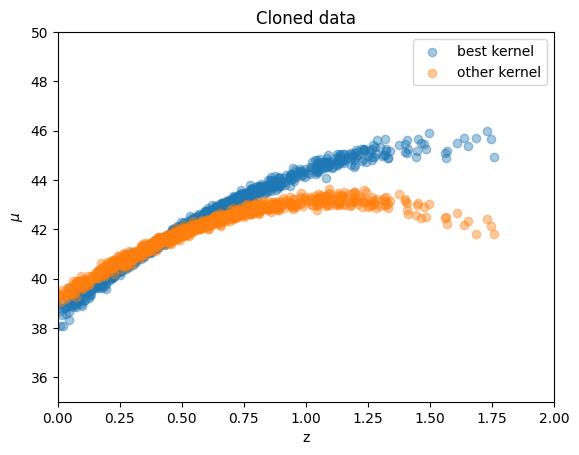

In [131]:
N = 1000
new_z_samples = kde.sample(N)               #N values that follow the pdf of z estimated by KDE

#now given the z (distributed as our sample)
mu_gpr=[]
mu_gprm=[]
for z in np.squeeze(new_z_samples):    
    mu_fit, sigma = gp_best.predict([[z]], return_std=True)
    mu_fitm, sigmam = gp3.predict([[z]], return_std=True)
    mu_gpr.append(np.random.normal(loc=mu_fit,scale=sigma))     #each data has also errors, which are randomly distributed with sigma
    mu_gprm.append(np.random.normal(loc=mu_fitm,scale=sigmam)) 
    
plt.scatter(new_z_samples,mu_gpr,alpha=0.4, label='best kernel')
plt.scatter(new_z_samples,mu_gprm,alpha=0.4, label='other kernel')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)
plt.legend()
plt.title("Cloned data");

### Part 3 : non linear fitting  following $\Lambda CDM$

I'm bayesian

In [132]:
import emcee
import scipy.stats as scistats
import corner
import dynesty
from astropy.cosmology import LambdaCDM

In [133]:
def generativemodel(z, H0, Om=1):
    cosmo_tmp = LambdaCDM(H0=H0, Om0=Om, Ode0=1-Om) #assuming a flat universe 
    return cosmo_tmp.distmod(z).value 

generativemodel(np.random.uniform(0,2,10), 50, 0.1)

array([42.7448499 , 44.85981385, 47.1579383 , 45.90640624, 39.52146982,
       46.75082056, 45.07764786, 45.37584526, 45.3156246 , 45.56197143])

### Likelihood definition
Parameter Hubble constant (H0) and Omega matter, $\Omega_{\Lambda}$ is $\Omega_{m}-1$ (flat universe)


In [134]:

def LogLikelihood(theta):
    Om,H0 = theta    
    if Om<0:
        return -np.inf
    else:
        mu_model = generativemodel(z_sample, H0, Om)
    
    return -0.5 * np.sum(((mu_sample - mu_model) / dmu) ** 2)                  #this is my implementation, without constant 

    "this version insted contains the normalization terms"
    #return np.sum(scistats.norm(loc=mu_model, scale=dmu).logpdf(mu_sample))    
     

### MCMC 

In [135]:
def Logprior(theta):
    Om,H0 = theta
    if 50 < H0 < 100 and 0.1 < Om < 1:      #UNIFORM PRIOR ON H0 AND OMEGA MATTER
        return 0.0
    return -np.inf

                   
def LogPosterior(theta):
    return LogLikelihood(theta) + Logprior(theta)

In [136]:
ndim = 2  # number of parameters in the model
nwalkers = 5  # number of MCMC walkers
nsteps = int(1e4)  # number of MCMC steps to take for each walker

#we assume Hubble constant=80 and Om = 0.5 as initial guess
starting_guesses = np.array([0.5,80]) + 1e-1* np.random.randn(nwalkers, ndim)       

print(starting_guesses.shape)

(5, 2)


In [137]:
#Where everything happens
sampler = emcee.EnsembleSampler(nwalkers, ndim, LogPosterior)  
sampler.run_mcmc(starting_guesses, nsteps);

In [138]:
samples = sampler.get_chain()

# Let's see the autocorrelation length
tau = sampler.get_autocorr_time()
print(tau)

[48.40472029 49.55107266]


Let's have a look the tha chains (everything OK?)

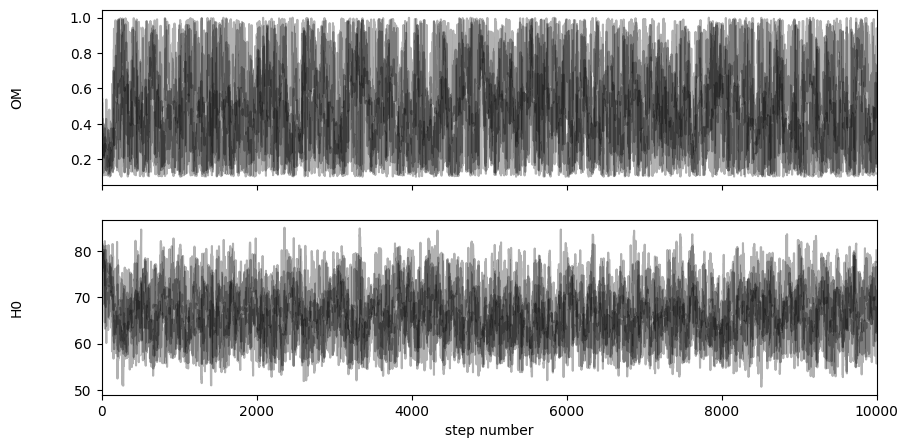

In [139]:
fig, axes = plt.subplots(2, figsize=(10, 5), sharex=True)
samples = sampler.get_chain()
labels = ["OM","H0"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

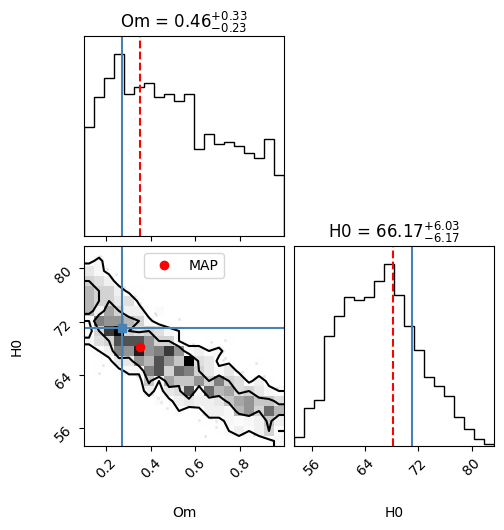

In [140]:
flat_samples = sampler.get_chain(discard=3*int(max(tau)), thin=int(max(tau)), flat=True)

log_prob = sampler.get_log_prob(discard=3*int(max(tau)), thin=int(max(tau)), flat=True) #the log probabilities evaluated at the MCMC samples
log_prob.shape #each value correspond to a set of parameters 
i_map = np.argmax(log_prob)                #index of the MAP

Om_map, H0_map = flat_samples[i_map]

fig = corner.corner(
    flat_samples, labels=["Om","H0"], levels=[0.68,0.95], show_titles=True, truths=[0.27,71])

axes = np.array(fig.axes).reshape((2, 2))  # 2x2 subplot: diagonali + scatter

# Scatter plot: Om vs H0
axes[1, 0].plot(Om_map, H0_map, "ro", label="MAP")
axes[1, 0].legend()

# Proiezioni 1D: Om e H0
axes[0, 0].axvline(Om_map, color="r", linestyle="--")
axes[1, 1].axvline(H0_map, color="r", linestyle="--")

(35.0, 50.0)

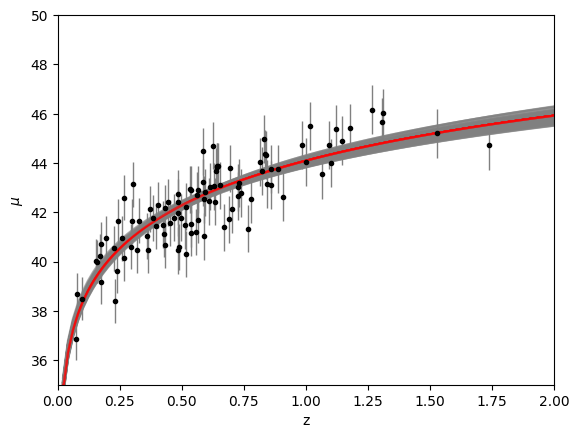

In [147]:
zlin = np.linspace(0,2,100)[1:]

samp100 = flat_samples[np.random.choice(len(flat_samples),size=100)] #100 random point in the posterior 

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')

Om_map, H0_map = flat_samples[i_map]                #Max posterior parameter 

for i in range(len(samp100)):
    Om, H0 = samp100[i]
    y = generativemodel(zlin,H0, Om)
    w = generativemodel(zlin,H0_map, Om_map)
    plt.plot(zlin,y,alpha=0.6, c='gray')
    plt.plot(zlin,w,alpha=0.6, c='red')

plt.xlabel("z")
plt.ylabel("$\mu$")
plt.xlim(0,2)
plt.ylim(35,50)